This is a companion notebook for the book [Deep Learning with Python, Third Edition](TODO). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

!pip install keras-nightly keras-hub-nightly --upgrade -q

In [95]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

### A spectrum of workflows

The design of the Keras API is guided by the principle of progressive disclosure of
complexity: make it easy to get started, yet make it possible to handle high-complexity use
cases, only requiring incremental learning at each step. Simple use cases should be easy
and approachable, and arbitrarily advanced workflows should be possible: no matter how
niche and complex the thing you want to do, there should be a clear path to it. A path that
builds upon the various things you’ve learned from simpler workflows. This means that you
can grow from beginner to expert and still use the same tools – only in different ways.
As such, there’s not a single “true” way of using Keras. Rather, Keras offers a spectrum
of workflows, from the very simple to the very flexible. There are different ways to build
Keras models, and different ways to train them, answering different needs.

For instance, you have a range of ways to build models and an array of ways to train
them, each representing a certain trade-off between usability and flexibility. You could be
using Keras like you would use Scikit-Learn – just calling fit() and letting the framework
do its thing – or you could be using it like NumPy – taking full control of every little detail.
Because all these workflows are based on shared APIs, such as Layer and Model,
components from any workflow can be used in any other workflow: they can all talk to each
other.

This means that everything you’re learning now as you’re getting started will still be
relevant once you’ve become an expert. You can get started easily and then gradually dive
into workflows where you’re writing more and more logic from scratch. You won’t have to
switch to an entirely different framework as you go from student to researcher, or from
data scientist to deep learning engineer.

This philosophy is not unlike that of Python itself! Some languages only offer one way to
write programs – for instance, object-oriented programming, or functional programming.
Meanwhile, Python is a multi-paradigm language: it offers a range of possible usage
patterns, which all work nicely together. This makes Python suitable for a wide range of
very different use cases: system administration, data science, machine learning
engineering, web development… or just learning how to program. Likewise, you can think of
Keras as the Python of deep learning: a user-friendly deep learning language that offers a
variety of workflows for different user profiles.

### Different ways to build Keras models

There are three APIs for building models in Keras:

The Sequential model, the most approachable API – it’s basically a
Python list. As such, it’s limited to simple stacks of layers.

The Functional API, which focuses on graph-like model architectures. It
represents a nice mid-point between usability and flexibility, and as such,
it’s the most commonly-used model-building API.

Model subclassing, a low-level option where you write everything
yourself from scratch. This is ideal if you want full control over every little
thing. However, you won’t get access to many built-in Keras features, and
you will be more at risk of making mistakes.

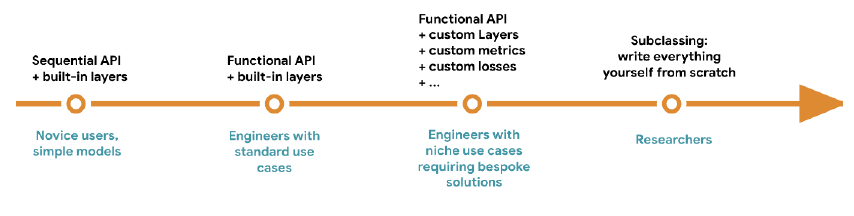

#### The Sequential model

The simplest way to build a Keras model is the Sequential model, which you already know
about:

In [96]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

Note that it’s possible to build the same model incrementally, via the add() method, similar
to the append() method of a Python list:

In [97]:
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

You’ve seen in Chapter 3 that layers only get built (which is to say, create their weights)
when they are called for the first time. That’s because the shape of the layers’ weights
depends on the shape of their input: until the input shape is known, they can’t be created.

In [98]:
model.weights

[]

As such, the Sequential model above does not have any weights until you actually call
it on some data, or call its build() method with an input shape:

In [99]:
model.build(input_shape=(None, 3))
model.weights

[<Variable path=sequential_3/dense_6/kernel, shape=(3, 64), dtype=float32, value=[[-1.79341733e-02  1.88700110e-01 -2.42537379e-01  2.01010585e-01
   -1.29233167e-01 -1.83994383e-01  6.49766624e-02 -2.70762295e-01
   -1.41740158e-01 -2.66611576e-04  2.96956062e-01 -2.26575181e-01
   -4.62904871e-02  1.95099264e-01  1.59719884e-02  2.92365789e-01
    2.64665544e-01 -8.71658623e-02  1.51449531e-01 -2.05859020e-01
    3.32795084e-02 -1.66634068e-01  1.42001718e-01  1.76006258e-02
    1.26862645e-01  1.78914517e-01  2.16253459e-01  1.15507364e-01
    2.20971107e-01 -1.28543735e-01 -2.67244339e-01 -1.76978648e-01
    1.78282827e-01  4.76992130e-03  7.24798441e-02  1.71222776e-01
   -1.81582123e-01  2.25783229e-01 -6.75985515e-02 -1.08517796e-01
   -3.10356319e-02  3.86179388e-02  1.11272871e-01 -3.40001285e-02
   -4.98316139e-02 -2.01200247e-01 -1.48861989e-01 -1.17990032e-01
   -2.54795015e-01  1.90427065e-01  2.10911632e-01 -7.67791271e-03
    2.90154219e-01 -2.90894300e-01 -1.80383772e-0

After the model is built, you can display its contents via the summary() method, which
comes in handy for debugging:

In [100]:
model.summary(line_length=80)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                   │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_7 (Dense)                   │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

As you can see, your model happens to be named “sequential_1”. You can actually give
names to everything in Keras – every model, every layer. Like this:

In [101]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary(line_length=80)

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)            │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ my_last_layer (Dense)             │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

Let's look at the model weights

In [ ]:
import numpy as np
print(model.weights)  # weights are only initialized after it knows the input data shape

print("Shape of the weights:")
print("Dense layer weights: ", np.asarray(model.weights[0]).shape)
print("Dense layer bias: ", np.asarray(model.weights[1]).shape)
print("Dense layer weights: ", np.asarray(model.weights[2]).shape)
print("Dense layer bias: ", np.asarray(model.weights[3]).shape)

x = np.random.randn(20,3)
print("Shape of the input:")
print(x.shape)  # 20 rows of data, 3 features each

y = model(x)
print("Shape of the output:")
print(y.shape)

[<Variable path=my_example_model/my_first_layer/kernel, shape=(3, 64), dtype=float32, value=[[-0.26230717  0.12201166  0.18593255 -0.12494084  0.23191404  0.27685237
   0.18821707 -0.20393471  0.18393019 -0.28176185 -0.06472211  0.28730077
   0.08630827  0.06431627 -0.04622886 -0.05930291 -0.08536091  0.24490887
  -0.2077279   0.17594653 -0.20443864 -0.08717428 -0.01274365  0.24249429
  -0.14556909 -0.01897836  0.2894503  -0.2801095  -0.09805399 -0.07686187
   0.07805917  0.06037399  0.29177886  0.05589458 -0.29500014  0.07100046
  -0.05292138  0.14575687  0.2839386   0.2061984   0.00806582  0.06675181
   0.16726285  0.05457428 -0.2897442  -0.27923685 -0.01974705 -0.03089622
  -0.06360088  0.08124739  0.21952707 -0.21940169 -0.185085   -0.17903817
   0.1519467  -0.27408323 -0.2552258   0.10199288 -0.25001973 -0.24481273
  -0.03544632 -0.21561322 -0.24891235 -0.24209559]
 [-0.05770737 -0.27919826 -0.11006218  0.25510204 -0.17791758 -0.20491546
  -0.13799164 -0.02231276 -0.11377497  0.26

/tmp/ipykernel_4095/557572170.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  plt.hist(np.array(model.weights[0]).ravel(), bins=20)


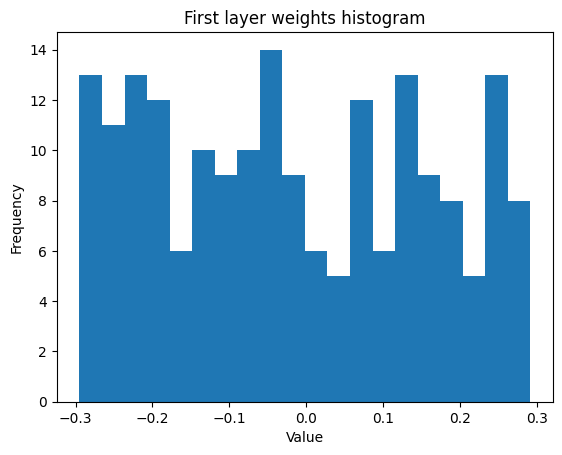

/tmp/ipykernel_4095/557572170.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  plt.hist(np.array(model.weights[2]).ravel(), bins=20)


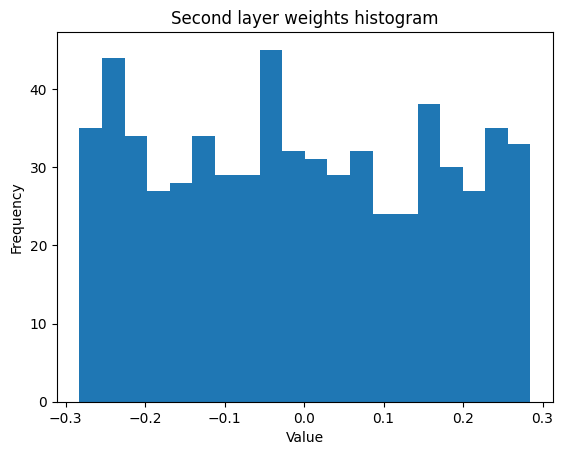

In [103]:
import matplotlib.pyplot as plt
    
plt.hist(np.array(model.weights[0]).ravel(), bins=20)
plt.title("First layer weights histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.hist(np.array(model.weights[2]).ravel(), bins=20)
plt.title("Second layer weights histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

When building a Sequential model incrementally, it’s useful to be able to print a summary
of what the current model looks like after you add each layer. But you can’t print a
summary until the model is built! There’s actually a way to have your Sequential model
get built on the fly: just declare the shape of the model’s inputs in advance. You can do this
via the Input class:

In [104]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))

Now you can use summary() to follow how the output shape of your model changes as you
add more layers:

In [105]:
model.summary(line_length=80)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                   │ (None, 64)               │           256 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
model.add(layers.Dense(10, activation="softmax"))
model.summary(line_length=80)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                   │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_9 (Dense)                   │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

This is a pretty common debugging workflow when dealing with layers that transform their
inputs in complex ways, such as the convolutional layers you’ll learn about in Chapter 8.

#### The Functional API

The Sequential model is easy to use, but its applicability is extremely limited: it can only
express models with a single input and a single output, applying one layer after the other in
a sequential fashion. In practice, it’s pretty common to encounter models with multiple
inputs (say, an image and its metadata), multiple outputs (different things you want to
predict about the data), or a non-linear topology.

In such cases, you’d build your model using the Functional API. This is what most Keras
models you’ll encounter in the wild use. It’s fun and powerful – it feels like playing with
LEGO bricks.

##### A simple example

Let’s start with something simple: the two-layer stack we used in the section above. Its
Functional API version looks like this:

In [107]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs, name="my_functional_model")

Let’s go over this step by step.

We started by declaring an Input (note that you can also give names to these input
objects, like everything else):

In [108]:
inputs = keras.Input(shape=(3,), name="my_input")

This inputs object holds information about the shape and dtype of the data that the model
will process:

In [109]:
inputs.shape  # None is the still unknown batch size, there are three features in the dataset

(None, 3)

In [110]:
inputs.dtype

'float32'

We call such an object a “symbolic tensor”. It doesn’t contain any actual data, but it
encodes the specifications of the actual tensors of data that the model will see when you
use it. It stands for future tensors of data.

Next, we created a layer and called it on the input:

In [111]:
features = layers.Dense(64, activation="relu")(inputs)

All Keras layers can be called both on real tensors of data, or on these symbolic tensors. In
the latter case, they return a new symbolic tensor, with updated shape and dtype
information:

In [112]:
features.shape

(None, 64)

After obtaining the final outputs, we instantiated the model by specifying its inputs and
outputs in the Model constructor:

In [113]:
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs, name="my_functional_model")

In [114]:
model.summary(line_length=80)

Model: "my_functional_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)             │ (None, 3)                │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_12 (Dense)                  │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_13 (Dense)                  │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

##### Multi-input, multi-output models

Unlike this toy model, most deep learning models don’t look like lists – they look like
graphs. They may, for instance, have multiple inputs or multiple outputs. It’s for this kind of
model that the Functional API really shines.

Let’s say you’re building a system to rank customer support tickets by priority and route
them to the appropriate department. Your model has three inputs:

The title of the ticket (text input)

The text body of the ticket (text input)

Any tags added by the user (categorical input, assumed here to be multihot
encoded)

We can encode the text inputs as arrays of ones and zeros of size vocabulary_size (see
Chapter 14 for detailed information about text encoding techniques).

Your model also has two outputs:

The priority score of the ticket, a scalar between 0 and 1 (sigmoid output)

The department that should handle the ticket (a softmax over the set of
departments)

You can build this model in a few lines with the Functional API:

In [115]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title")   # define inputs
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

features = layers.Concatenate()([title, text_body, tags])   # combine inputs into a single tensor
features = layers.Dense(64, activation="relu", name="dense_features")(features)  # intermediate dense layer

priority = layers.Dense(1, activation="sigmoid", name="priority")(features)   # define model outputs
department = layers.Dense(
    num_departments, activation="softmax", name="department"
)(features)

model = keras.Model(    # create the model
    inputs=[title, text_body, tags],
    outputs=[priority, department],
)

The Functional API is a simple, LEGO-like, yet very flexible way to define arbitrary graphs of
layers like these.

##### Training a multi-input, multi-output model

You can train your model in much the same way as you would train a Sequential model,
by calling fit() with lists of input and output data. These lists of data should respect the
same order as what you passed to the Model() constructor.

In [116]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))   # create dummy input data
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))    # create dummy labels and targets
department_data = np.random.randint(0, 2, size=(num_samples, num_departments))

model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)
model.fit(
    [title_data, text_body_data, tags_data],
    [priority_data, department_data],
    epochs=1,
)
model.evaluate(
    [title_data, text_body_data, tags_data], [priority_data, department_data]
)
priority_preds, department_preds = model.predict(
    [title_data, text_body_data, tags_data]
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - department_accuracy: 0.2938 - department_loss: 11.6081 - loss: 11.9206 - priority_loss: 0.3125 - priority_mean_absolute_error: 0.4811
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - department_accuracy: 0.1891 - department_loss: 10.1096 - loss: 10.4267 - priority_loss: 0.3170 - priority_mean_absolute_error: 0.4857
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [117]:
# let's look at the shape of the input data
print(title_data.shape)
print(text_body_data.shape)
print(tags_data.shape)
print(priority_data.shape)
print(department_data.shape)

(1280, 10000)
(1280, 10000)
(1280, 100)
(1280, 1)
(1280, 4)


If you don’t want to rely on input order (for instance because you have many inputs or
outputs), you can also leverage the names you gave to the Input objects and to the output
layers, and pass data via dictionaries:

In [27]:
model.compile(
    optimizer="adam",
    loss={
        "priority": "mean_squared_error",
        "department": "categorical_crossentropy",
    },
    metrics={
        "priority": ["mean_absolute_error"],
        "department": ["accuracy"],
    },
)
model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
    epochs=1,
)
model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
)
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - department_accuracy: 0.3852 - department_loss: 99.8278 - loss: 100.1605 - priority_loss: 0.3327 - priority_mean_absolute_error: 0.5008 
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - department_accuracy: 0.3172 - department_loss: 96.5967 - loss: 96.9294 - priority_loss: 0.3327 - priority_mean_absolute_error: 0.5008
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


##### The power of the Functional API: access to layer connectivity

A Functional model is an explicit graph data structure. This makes it possible to inspect how
layers are connected and reuse previous graph nodes (which are layer outputs) as part of
new models. It also nicely fits the “mental model” that most researchers use when thinking
about a deep neural network: a graph of layers.

This enables two important use cases: model visualization, and feature extraction. Let’s
take a look.

#### Plotting layer connectivity

Let’s visualize the connectivity of the model we just defined (the topology of the model).
You can plot a Functional model as a graph with the plot_model() utility:

To make the plotting work, you must pip install pydot, then install graphviz.  Graphviz is installed as an executable, not through pip.

https://graphviz.gitlab.io/download/

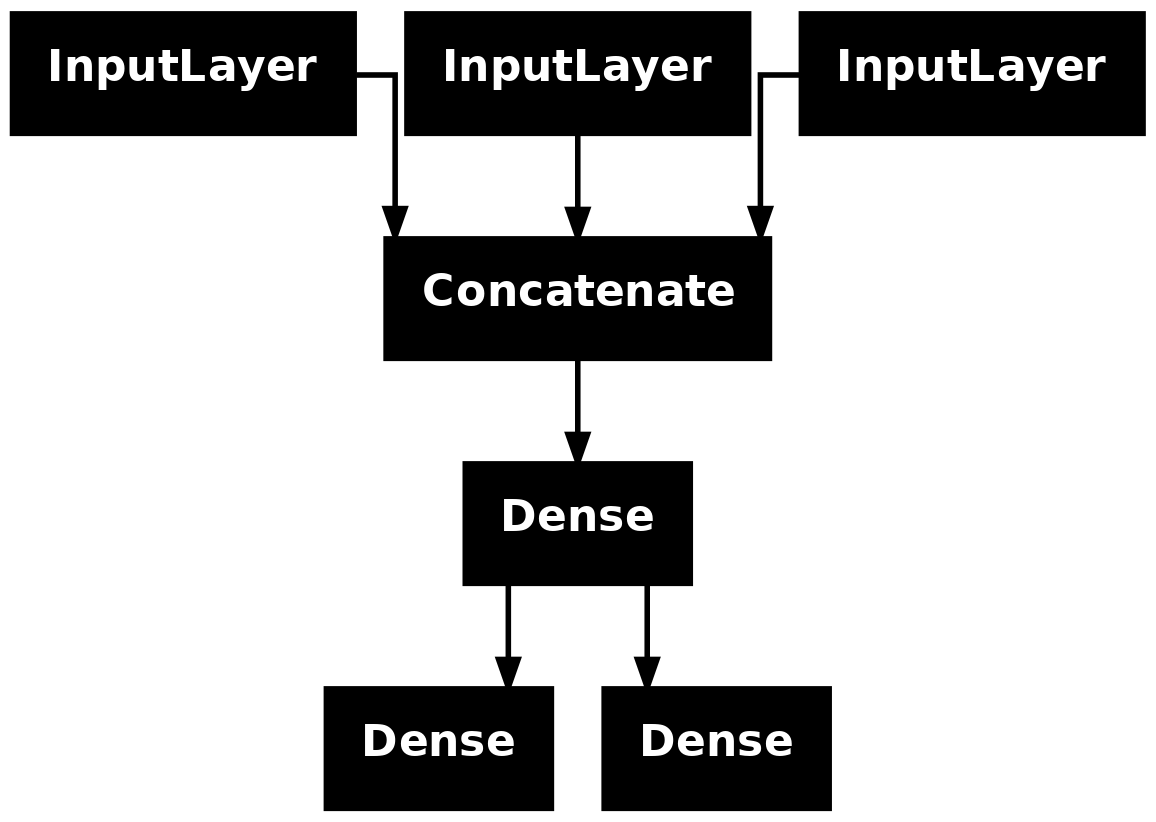

In [28]:
keras.utils.plot_model(model, "ticket_classifier.png")

You can add to this plot the input and output shapes of each layer in the model, as well as
layer names (rather than just layer types), which can be helpful during debugging:

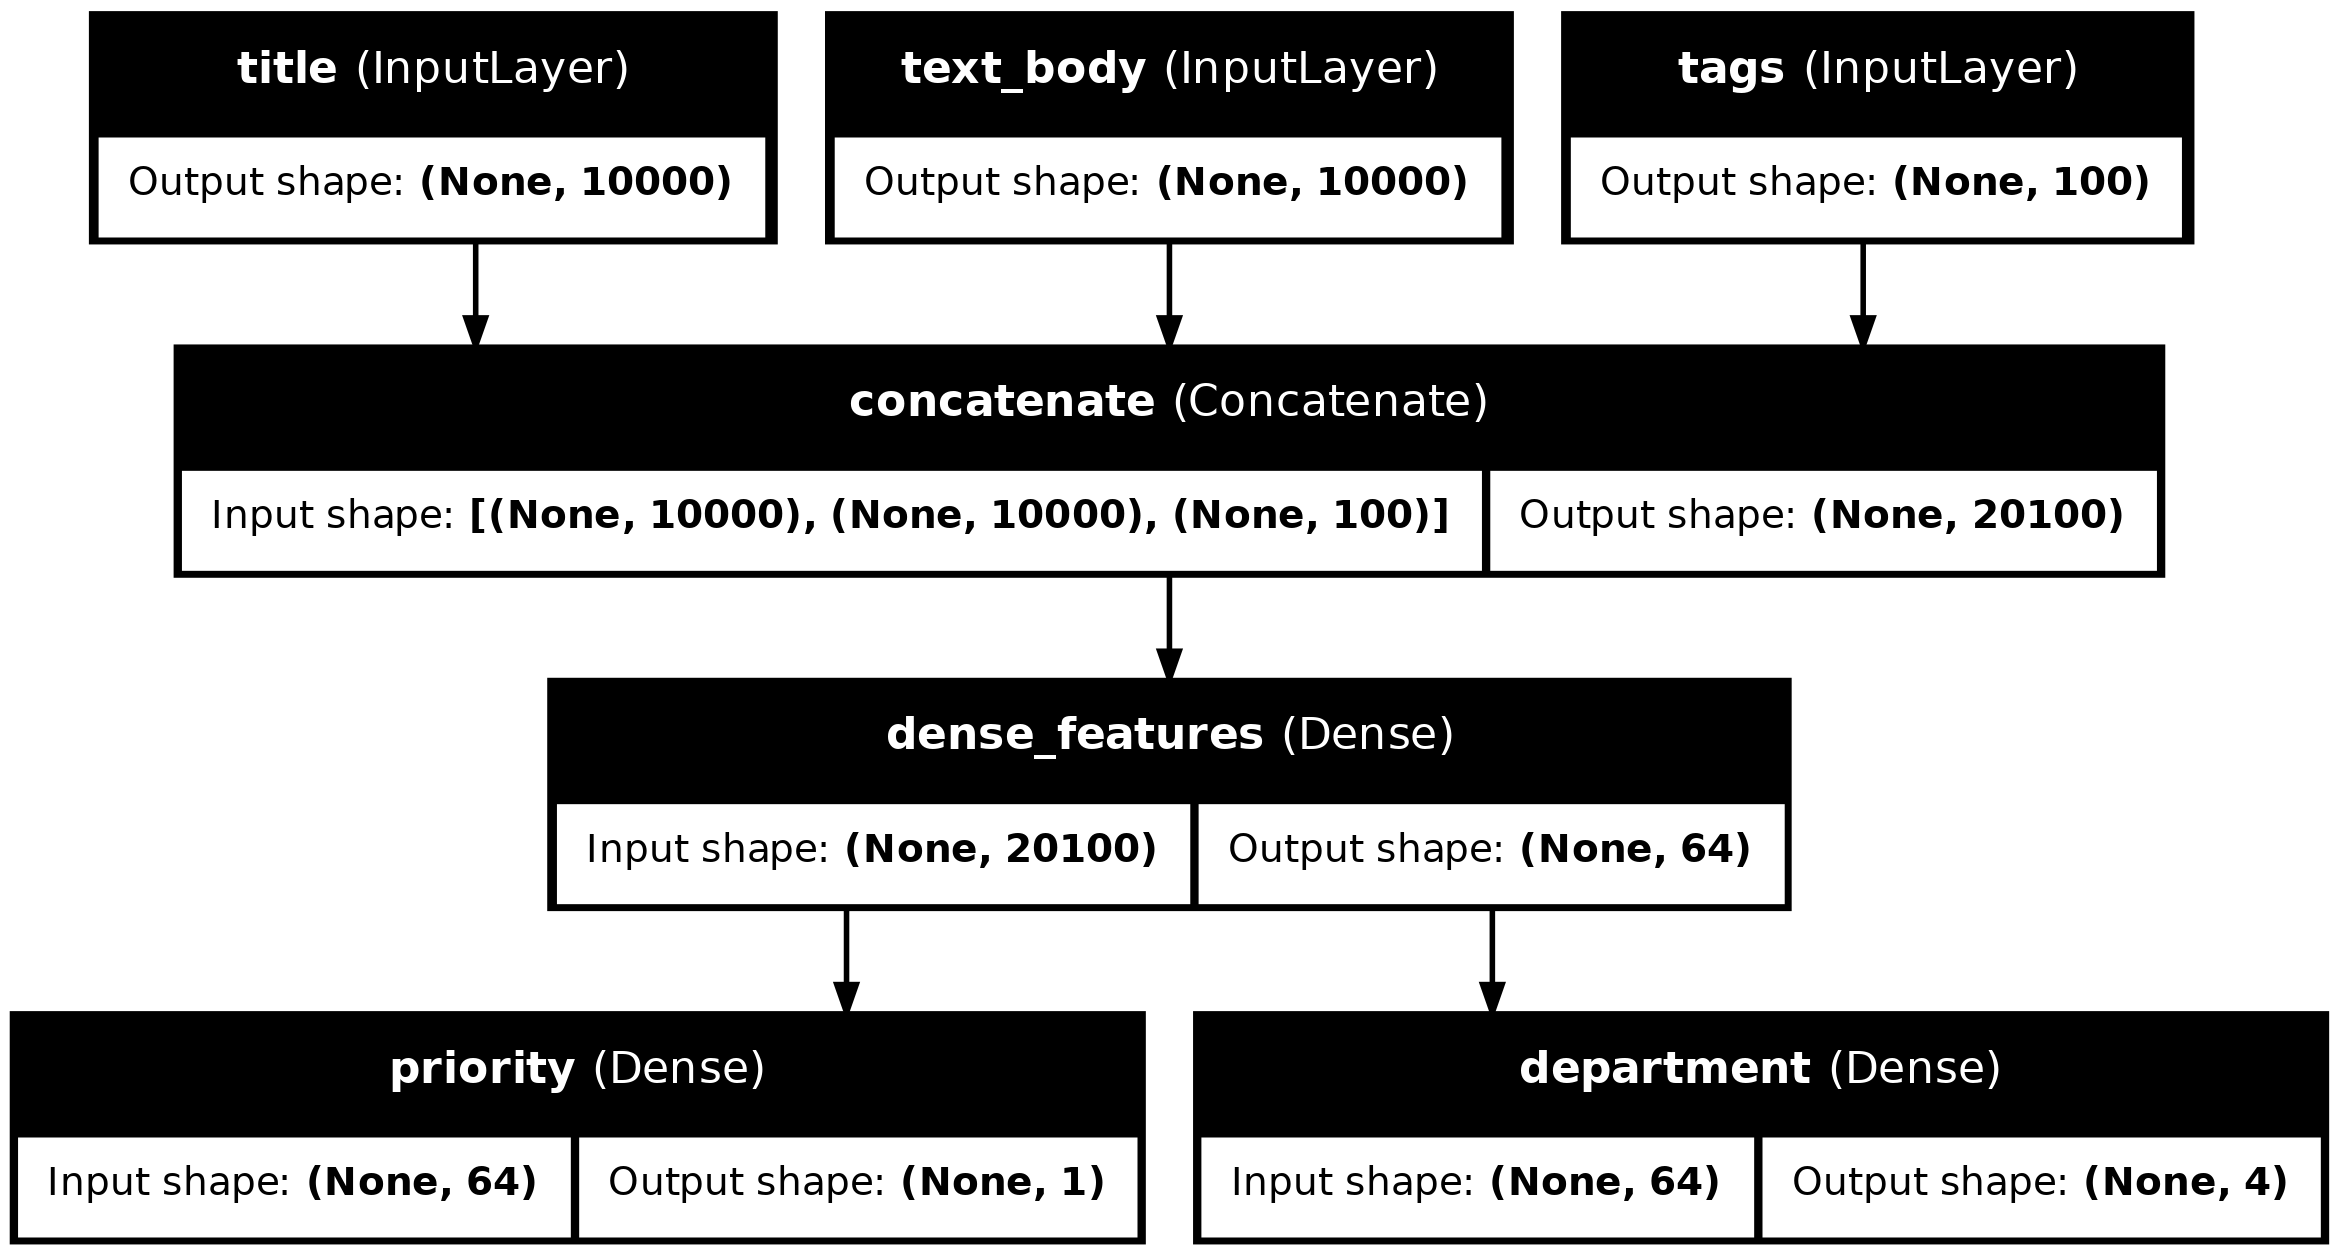

In [29]:
keras.utils.plot_model(
    model,
    "ticket_classifier_with_shape_info.png",
    show_shapes=True,
    show_layer_names=True,
)

#### Feature extraction with a Functional model

Access to layer connectivity also means that you can inspect and reuse individual nodes
(layer calls) in the graph. The model property model.layers provides the list of layers that
make up the model, and for each layer you can query layer.input and layer.output:

In [30]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_features, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

Many errors you will encounter are due to mismatches on input data shapes

In [118]:
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

Checking the output shapes for layer 3

In [119]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_25>

This enables you to do feature extraction: creating models that reuse intermediate features
from another model.

Let’s say you want to add another output to the model we defined above – you want to
also predict an estimate of how long a given issue ticket will take to resolve, a kind of
difficulty rating. You could do this via a classification layer over 3 categories – “quick”,
“medium”, “difficult”. You don’t need to recreate and retrain a model from scratch! You can
just start from the intermediate features of your previous model, since you have access to
them. Like this:

In [31]:
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

In [32]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>

In [33]:
features = model.layers[4].output
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

new_model = keras.Model(
    inputs=[title, text_body, tags], outputs=[priority, department, difficulty]
)

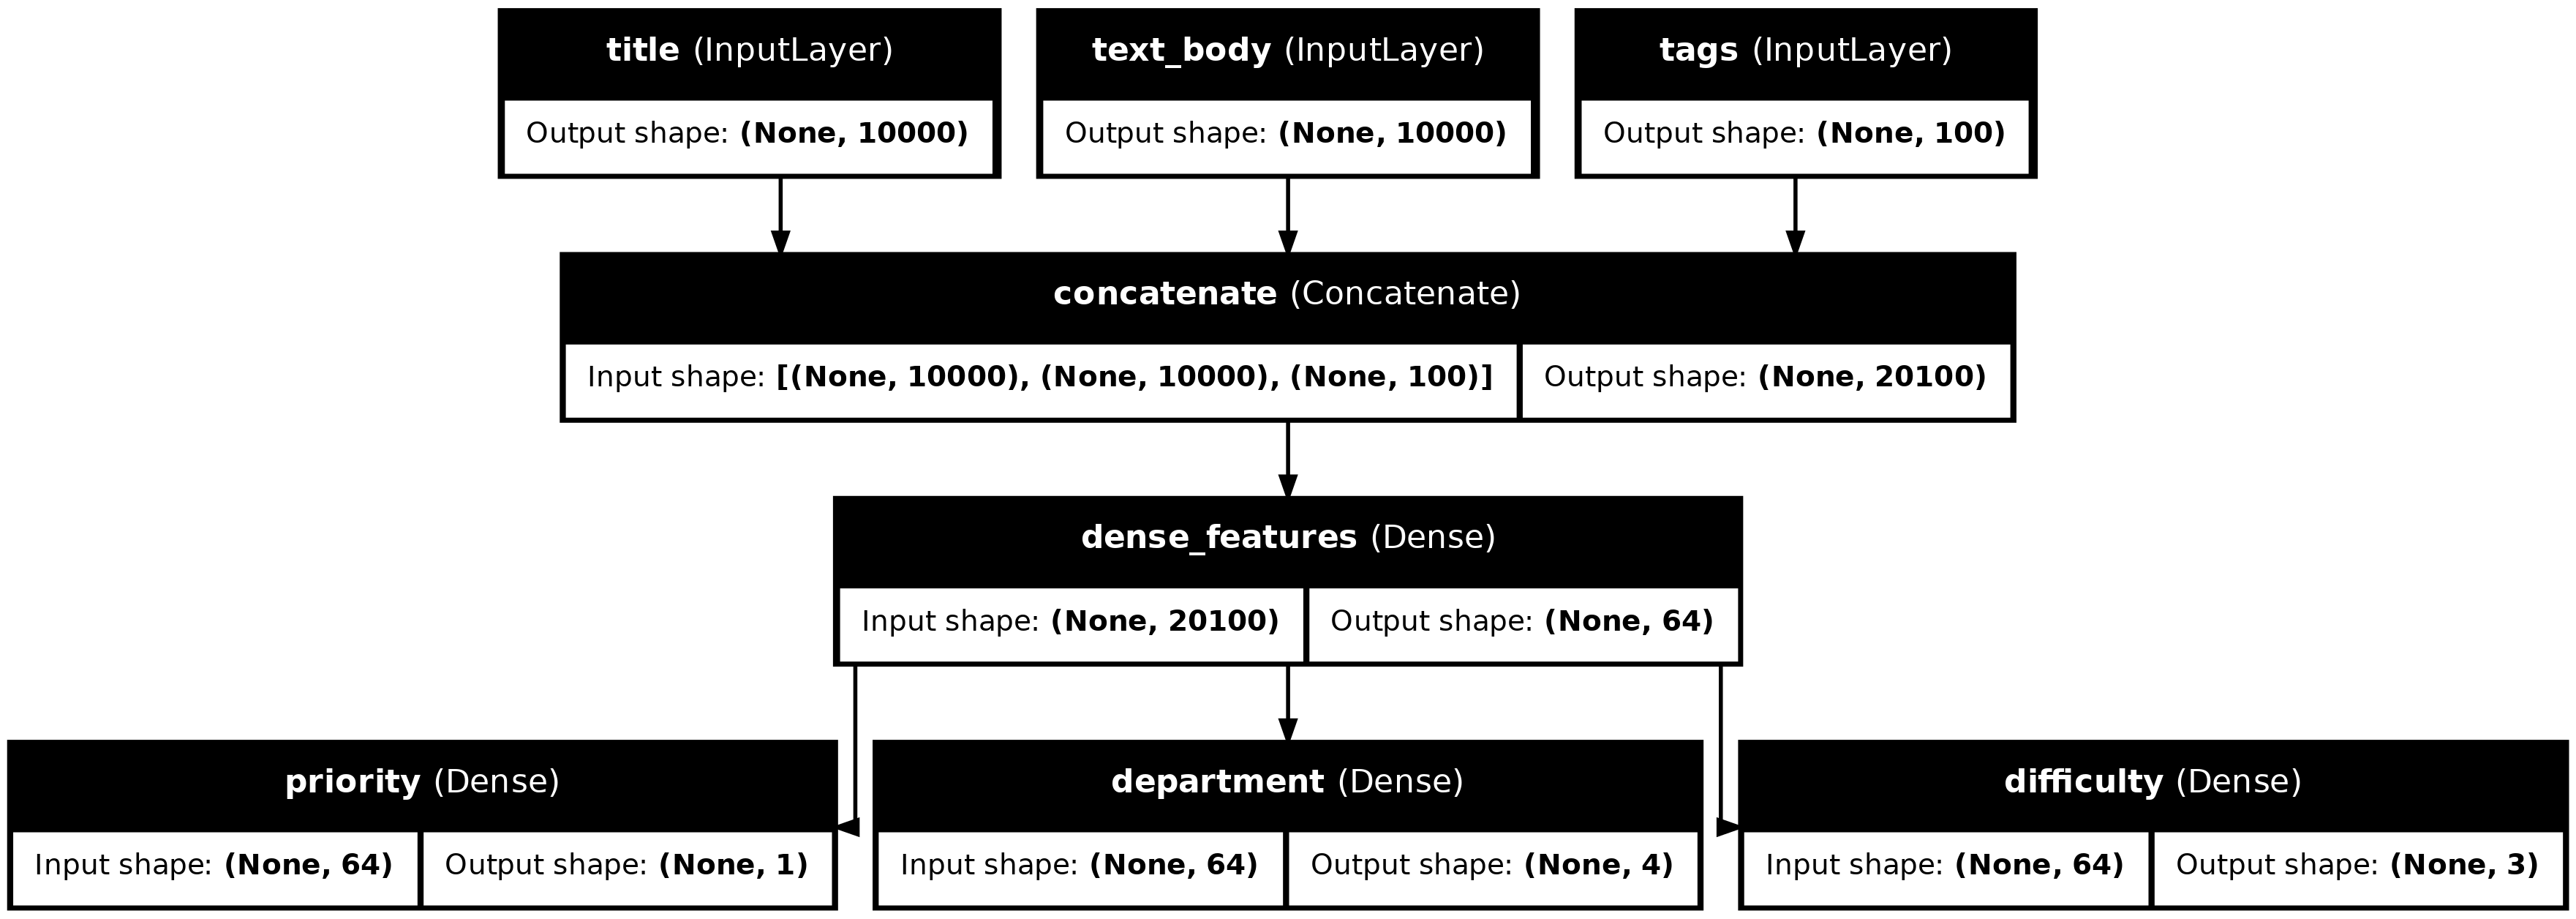

In [34]:
keras.utils.plot_model(
    new_model,
    "updated_ticket_classifier.png",
    show_shapes=True,
    show_layer_names=True,
)

#### Subclassing the `Model` class

The last model building pattern you should know about is the most advanced one: Model
subclassing. You’ve already learned in Chapter 3 how to subclass the Layer class to create
custom layers. Subclassing Model is pretty similar:

In the __init__ method, define the layers the model will use.

In the call method, define the forward pass of the model, reusing the
layers previously created.

Instantiate your subclass and call it on data to create its weights.

##### Rewriting our previous example as a subclassed model

Let’s take a look at a simple example: we will reimplement the customer support ticket
management model using a Model subclass.

In [35]:
class CustomerTicketModel(keras.Model):
    def __init__(self, num_departments):
        super().__init__()  # always call the super constructor
        self.concat_layer = layers.Concatenate()    # define the layers in the constructor
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(
            num_departments, activation="softmax"
        )

    def call(self, inputs):   # define the forward pass in the call() method
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]

        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

Once you’ve defined the model, you can instantiate it. Note that it will only create its
weights the first time you call it on some data – much like Layer subclasses.

In [36]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

So far, everything looks very similar to Layer subclassing, a workflow you’ve already
encountered in Chapter 3. What, then, is the difference between a Layer subclass and a
Model subclass? It’s simple: a “layer” is a building block you use to create models, and a
“model” is the top-level object that you will actually train, export for inference, etc. In
short, a Model has a fit(), evaluate(), and predict() method. Layers don’t. Other than
that, the two classes are virtually identical (another difference is that you can save a model
to a file on disk – which we will cover in a few sections).

You can compile and train a Model subclass just like a Sequential or Functional model:

In [37]:
model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "categorical_crossentropy"],   # The structure of what you pass as the loss and metrics must match exactly what gets returned by call() – since we returned a list of two elements, so should loss and metrics be lists of two elements.
    metrics=[["mean_absolute_error"], ["accuracy"]],
)
'''The structure of the input data must match exactly what is expected by the call()
method, and the structure of the target data must match exactly what gets returned by
the call() method. Here, the input data must be a dict with 3 keys (‘title’,
‘text_body’, and ‘tags’) and the target data must be a list of two elements.'''

model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
    epochs=1,
)
model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
)
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2031 - categorical_crossentropy_loss: 7.7987 - loss: 8.1293 - mean_absolute_error: 0.4989 - mean_squared_error_loss: 0.3306 
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3180 - categorical_crossentropy_loss: 2.8325 - loss: 3.1652 - mean_absolute_error: 0.5008 - mean_squared_error_loss: 0.3327
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


The Model subclassing workflow is the most flexible way to build a model: it enables you to
build models that cannot be expressed as directed acyclic graphs of layers – imagine, for
instance, a model where the call() method uses layers inside a for loop, or even calls
them recursively. Anything is possible – you’re in charge.

##### Beware: what subclassed models don't support

This freedom comes at a cost: with subclassed models, you are responsible for more of the
model logic, which means your potential error surface is much larger. As a result, you will
have more debugging work to do. You are developing a new Python object, not just
snapping together LEGO bricks.

Functional and subclassed models are also substantially different in nature: a Functional
model is an explicit data structure – a graph of layers, which you can view, inspect, and
modify. Meanwhile, a subclassed model is a piece of bytecode – a Python class with a
call() method that contains raw code. This is the source of the subclassing workflow’s
flexibility – you can just code up whatever functionality you like – but it introduces new
limitations.

For instance, because the way layers are connected to each other is hidden inside the
body of the call() method, you cannot access that information. Calling summary() will not
display layer connectivity, and you cannot plot the model topology via plot_model().

Likewise, if you have a subclassed model, you cannot access the nodes of the graph of
layers to do feature extraction – because there is simply no graph. Once the model is
instantiated, its forward pass becomes a complete blackbox.

#### Mixing and matching different components

Crucially, choosing one of these patterns – the Sequential model, the Functional API,
Model subclassing – does not lock you out of the others. All models in the Keras API can
smoothly interoperate with each other, whether they’re Sequential models, Functional
models, or subclassed models written from scratch. They’re all part of the same spectrum
of workflows.

For instance, you can use a subclassed layer or model in a Functional model:

In [38]:
class Classifier(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = "sigmoid"
        else:
            num_units = num_classes
            activation = "softmax"
        self.dense = layers.Dense(num_units, activation=activation)

    def call(self, inputs):
        return self.dense(inputs)

inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation="relu")(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

Inversely, you can use a Functional model as part of a subclassed layer or model:

In [39]:
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation="relu")
        self.classifier = binary_classifier

    def call(self, inputs):
        features = self.dense(inputs)
        return self.classifier(features)

model = MyModel()

#### Remember: use the right tool for the job

You’ve learned about the spectrum of workflows for building Keras models, from the
simplest workflow – the Sequential model – to the most advanced one, model subclassing.
When should you use one over the other? Each one has its pros and cons – pick the one
most suitable for the job at hand.

In general, the Functional API provides you with a pretty good trade-off between easeof-
use and flexibility. It also gives you direct access to layer connectivity, which is very
powerful for use cases such as model plotting or feature extraction. If you can use the
Functional API – that is, if your model can be expressed as a directed acyclic graph of
layers – I recommend using it over model subclassing.

Going forward, all examples in this book will use the Functional API – simply because all
of the models we will work with are expressible as graphs of layers. We will, however, make
frequent use of subclassed layers. In general, using Functional models that include
subclassed layers provides the best of both worlds: high development flexibility while
retaining the advantages of the Functional API.

### Using built-in training and evaluation loops

The principle of progressive disclosure of complexity – access to a spectrum of workflows
that go from dead easy to arbitrarily flexible, one step at a time – also applies to model
training. Keras provides you with different workflows for training models – it can be as
simple as calling fit() on your data, or as advanced as writing a new training algorithm
from scratch.

You are already familiar with the compile(), fit(), evaluate(), predict() workflow.
As a reminder, it looks like this:

In [40]:
from keras.datasets import mnist

def get_mnist_model():    # create model in a function so it can be reused
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()    # load data
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

In [41]:
model = get_mnist_model()
model.compile(    # compile using Adam optimizer and sparse categorical crossentropy loss
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)    # Use evaluate() to compute the loss and metrics on new data.
predictions = model.predict(test_images)    # Use predict() to compute classification probabilities on new data.

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9133 - loss: 0.2894 - val_accuracy: 0.9591 - val_loss: 0.1360
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9550 - loss: 0.1493 - val_accuracy: 0.9706 - val_loss: 0.0983
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9647 - loss: 0.1168 - val_accuracy: 0.9735 - val_loss: 0.0865
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9745 - loss: 0.0848
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


There are a few ways you can customize this simple workflow:

Providing your own custom metrics

Passing callbacks to the fit() method to schedule actions to be taken at
specific points during training

#### Writing your own metrics

Metrics are key to measuring the performance of your model – in particular, to measure the
difference between its performance on the training data and its performance on the test
data. Commonly used metrics for classification and regression are already part of the builtin
keras.metrics module – most of the time, that’s what you will use. But if you’re doing
anything out of the ordinary, you will need to be able to write your own metrics. It’s simple!
A Keras metric is a subclass of the keras.metrics.Metric class. Similarly to layers, a
metric has an internal state stored in Keras variables. Unlike layers, these variables aren’t
updated via backpropagation, so you have to write the state update logic yourself – which
happens in the update_state() method.

For example, here’s a simple custom metric that measures the Root Mean Squared Error
(RMSE).

In [42]:
from keras import ops

'''The add_weight() method in Keras is a function of the keras.layers.Layer class, used to add a new variable (weight) to a custom Keras layer. 
This method is typically called within the build() method of a custom layer, as it allows for the creation of weights whose shapes might depend 
on the input shape to the layer, which is only known during the first call to the layer's call() method.'''

''' Implement the state update logic in update_state(). The y_true argument is the
targets (or labels) for one batch, while y_pred represents the corresponding
predictions from the model. To match our MNIST model, we expect categorical
predictions and integer labels. You can ignore the sample_weight argument, we won’t
use it here.'''

class RootMeanSquaredError(keras.metrics.Metric):    # subclass the metrics class
    def __init__(self, name="rmse", **kwargs):    # define the state variables in the constructor
        super().__init__(name=name, **kwargs)     # always call the super()
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")    # 
        self.total_samples = self.add_weight(
            name="total_samples", initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = ops.one_hot(y_true, num_classes=ops.shape(y_pred)[1])
        mse = ops.sum(ops.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        num_samples = ops.shape(y_pred)[0]
        self.total_samples.assign_add(num_samples)

    def result(self):   # return current value of metric
        return ops.sqrt(self.mse_sum / self.total_samples)

    def reset_state(self):   # reset metric to zero between epochs
        self.mse_sum.assign(0.)
        self.total_samples.assign(0)

In [43]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", RootMeanSquaredError()],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9123 - loss: 0.2898 - rmse: 0.3621 - val_accuracy: 0.9609 - val_loss: 0.1340 - val_rmse: 0.2448
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9563 - loss: 0.1459 - rmse: 0.2603 - val_accuracy: 0.9665 - val_loss: 0.1107 - val_rmse: 0.2261
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9646 - loss: 0.1130 - rmse: 0.2324 - val_accuracy: 0.9727 - val_loss: 0.0936 - val_rmse: 0.2059
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9717 - loss: 0.0882 - rmse: 0.2048


#### Using Callbacks

Launching a training run on a large dataset for tens of epochs using model.fit() can be a
bit like launching a paper airplane: past the initial impulse, you don’t have any control over
its trajectory or its landing spot. If you want to avoid bad outcomes (and thus wasted paper
airplanes), it’s smarter to use not a paper plane, but a drone that can sense its
environment, send data back to its operator, and automatically make steering decisions
based on its current state. The Keras callbacks API will help you transform your call to
model.fit() from a paper airplane into a smart, autonomous drone that can self-introspect
and dynamically take action.

A callback is an object (a class instance implementing specific methods) that is passed to
the model in the call to fit() and that is called by the model at various points during
training. It has access to all the available data about the state of the model and its
performance, and it can take action: interrupt training, save a model, load a different
weight set, or otherwise alter the state of the model.

Here are some examples of ways you can use callbacks:

Model checkpointing — Saving the current state of the model at
different points during training.

Early stopping — Interrupting training when the validation loss is no
longer improving (and of course, saving the best model obtained during
training).

Dynamically adjusting the value of certain parameters during
training — Such as the learning rate of the optimizer.

Logging training and validation metrics during training, or
visualizing the representations learned by the model as they’re
updated — The fit() progress bar that you’re familiar with is in fact a
callback!

The keras.callbacks module includes a number of built-in callbacks (this is not an
exhaustive list):

keras.callbacks.ModelCheckpoint

keras.callbacks.EarlyStopping

keras.callbacks.LearningRateScheduler

keras.callbacks.ReduceLROnPlateau

keras.callbacks.CSVLogger

##### The `EarlyStopping` and `ModelCheckpoint` callbacks

When you’re training a model, there are many things you can’t predict from the start. In
particular, you can’t tell how many epochs will be needed to get to an optimal validation
loss. Our examples so far have adopted the strategy of training for enough epochs that you
begin overfitting, using the first run to figure out the optimal number of epochs, and then
finally launching a new training run from scratch using this optimal number. Of course, this
approach is wasteful. A much better way to handle this is to stop training when you
measure that the validation loss is no longer improving. This can be achieved using the
EarlyStopping callback.

The EarlyStopping callback interrupts training once a target metric being monitored
has stopped improving for a fixed number of epochs. For instance, this callback allows you
to interrupt training as soon as you start overfitting, thus avoiding having to retrain your
model for a smaller number of epochs. This callback is typically used in combination with
ModelCheckpoint, which lets you continually save the model during training (and,
optionally, save only the current best model so far: the version of the model that achieved
the best performance at the end of an epoch):

In [44]:
callbacks_list = [  # a list
    keras.callbacks.EarlyStopping(    # interrupt training when a monitored metric has stopped improving
        monitor="accuracy",    # monitors models validation accuracy
        patience=1,    # stops training after 1 epoch of no improvement
    ),
    keras.callbacks.ModelCheckpoint(    # save current weights after each epoch
        filepath="checkpoint_path.keras",  # filename that model is saved to
        monitor="val_loss",   # only save if validation loss has improved
        save_best_only=True,
    ),
]
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],    # monitors model's training and validation accuracy.  Must include this since that is our early stopping criteria
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=callbacks_list,
    validation_data=(val_images, val_labels),    # since we are monitoring validation loss, we need to provide validation data
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9141 - loss: 0.2869 - val_accuracy: 0.9578 - val_loss: 0.1419
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9545 - loss: 0.1489 - val_accuracy: 0.9709 - val_loss: 0.0990
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9650 - loss: 0.1145 - val_accuracy: 0.9724 - val_loss: 0.0875
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9702 - loss: 0.0939 - val_accuracy: 0.9763 - val_loss: 0.0830
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9735 - loss: 0.0833 - val_accuracy: 0.9790 - val_loss: 0.0747
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9769 - loss: 0.0746 - val_accuracy: 0.9772 - val_loss: 0.0764
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9777 - loss: 0.0715 - val_accuracy: 0.9798 - val_loss: 0.0725
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9800 - loss: 0

You can also manually save the model with: model.save("my_checkpoint_path.keras")

To reload the model:

In [45]:
model = keras.models.load_model("checkpoint_path.keras")

#### Writing your own callbacks

If you need to take a specific action during training that isn’t covered by one of the built-in
callbacks, you can write your own callback. Callbacks are implemented by subclassing the
class keras.callbacks.Callback. You can then implement any number of the following
transparently-named methods, which are called at various points during training:

on_epoch_begin(epoch, logs) #1

on_epoch_end(epoch, logs) #2

on_batch_begin(batch, logs) #3

on_batch_end(batch, logs) #4

on_train_begin(logs) #5

on_train_end(logs) #6

#1 Called at the start of every epoch

#2 Called at the end of every epoch

#3 Called right before processing each batch

#4 Called right after processing each batch

#5 Called at the start of training

#6 Called at the end of training

These methods are all called with a logs argument, which is a dictionary containing
information about the previous batch, epoch, or training run: training and validation
metrics, and so on. The on_epoch_* and on_batch_* methods also take the epoch or batch
index as first argument (an integer).

Here’s a simple example callback that saves a list of per-batch loss values during training
and plots these values at the end of each epoch:

In [46]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(
            range(len(self.per_batch_losses)),
            self.per_batch_losses,
            label="Training loss for each batch",
        )
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}", dpi=300)
        self.per_batch_losses = []

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9127 - loss: 0.2891 - val_accuracy: 0.9587 - val_loss: 0.1384
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9560 - loss: 0.1450 - val_accuracy: 0.9682 - val_loss: 0.1041
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9651 - loss: 0.1152 - val_accuracy: 0.9719 - val_loss: 0.0903
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9695 - loss: 0.0974 - val_accuracy: 0.9761 - val_loss: 0.0828
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9735 - loss: 0.0849 - val_accuracy: 0.9753 - val_loss: 0.0815
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9752 - loss: 0.0769 - val_accuracy: 0.9787 - val_loss: 0.0730
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9781 - loss: 0.0699 - val_accuracy: 0.9767 - val_loss: 0.0791
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9795 - loss: 0

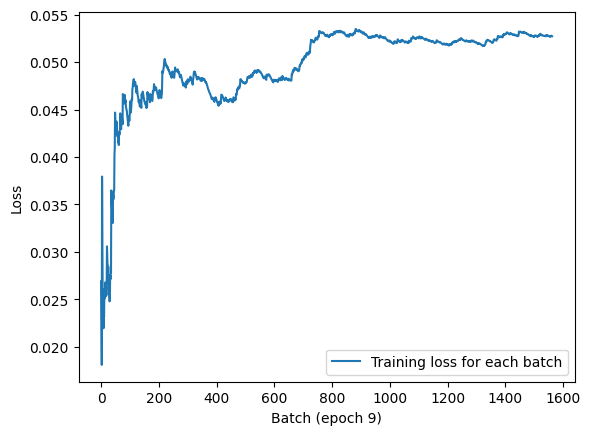

In [47]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=[LossHistory()],
    validation_data=(val_images, val_labels),
)

#### Monitoring and visualization with TensorBoard

To do good research or develop good models, you need rich, frequent feedback about
what’s going on inside your models during your experiments. That’s the point of running
experiments: to get information about how well a model performs—as much information as
possible. Making progress is an iterative process – a loop: you start with an idea and
express it as an experiment, attempting to validate or invalidate your idea. You run this
experiment and process the information it generates. This inspires your next idea. The
more iterations of this loop you’re able to run, the more refined and powerful your ideas
become. Keras helps you go from idea to experiment in the least possible time, and fast
GPUs can help you get from experiment to result as quickly as possible. But what about
processing the experiment results? That’s where TensorBoard comes in.

TensorBoard is a browser-based application that you can run locally. It’s the best way to
monitor everything that goes on inside your model during training. With TensorBoard, you
can:

Visually monitor metrics during training

Visualize your model architecture

Visualize histograms of activations and gradients

Explore embeddings in 3D

If you’re monitoring more information than just the model’s final loss, you can develop a
clearer vision of what the model does and doesn’t do, and you can make progress more
quickly.

The easiest way to use TensorBoard with a Keras model and the fit() method is the
keras.callbacks.TensorBoard callback.

In the simplest case, just specify where you want the callback to write logs, and you’re
good to go:

In [48]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

tensorboard = keras.callbacks.TensorBoard(
    log_dir="/full_path_to_your_log_dir",
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(val_images, val_labels),
    callbacks=[tensorboard],
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9113 - loss: 0.2930 - val_accuracy: 0.9587 - val_loss: 0.1411
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9547 - loss: 0.1486 - val_accuracy: 0.9683 - val_loss: 0.1024
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9647 - loss: 0.1143 - val_accuracy: 0.9725 - val_loss: 0.0872
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9692 - loss: 0.0970 - val_accuracy: 0.9746 - val_loss: 0.0826
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9729 - loss: 0.0860 - val_accuracy: 0.9755 - val_loss: 0.0831
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9767 - loss: 0.0730 - val_accuracy: 0.9796 - val_loss: 0.0728
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9776 - loss: 0.0699 - val_accuracy: 0.9771 - val_loss: 0.0772
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9794 - l

Once the model starts running, it will write logs at the target location. If you are running
your Python script on a local machine, you can then launch the local TensorBoard server
using the following command (note that the tensorboard executable should already be
available if you have installed TensorFlow via pip; if not, you can install TensorBoard
manually via pip install tensorboard).

%tensorboard --logdir /full_path_to_your_log_dir

You can then navigate to the URL that the command returns to access the TensorBoard
interface.

If you are running your script in a Colab notebook, you can run an embedded
TensorBoard instance as part of your notebook, using the following commands:

%load_ext tensorboard

%tensorboard --logdir /full_path_to_your_log_dir

In the TensorBoard interface, you will be able to monitor live graphs of your training and
evaluation metrics:

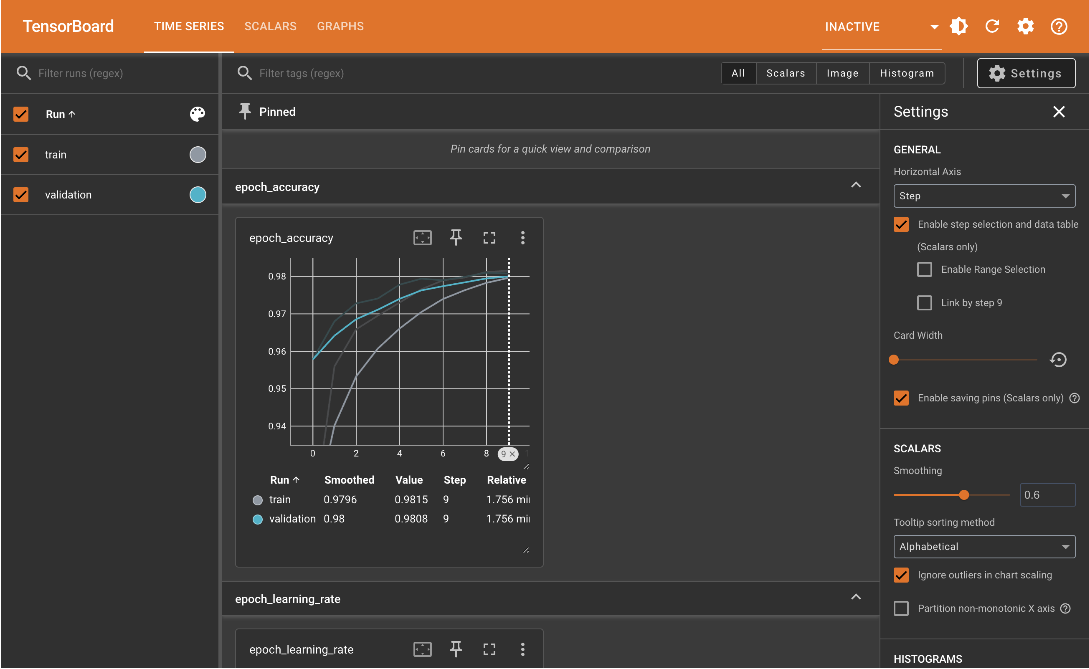

I found the above does not work with Windows and Docker, I run tensorboard from docker bash command line with: tensorboard --logdir /full_path_to_your_log_dir --bind_all

Then open http://localhost:6006 in Chrome/Firefox

Tutorial is here:  https://www.tensorflow.org/tensorboard/get_started

### Writing your own training and evaluation loops

The fit() workflow strikes a nice balance between ease of use and flexibility. It’s what you
will use most of the time. However, it isn’t meant to support everything a deep learning
researcher may want to do – even with custom metrics, custom losses, and custom
callbacks.

After all, the built-in fit() workflow is solely focused on supervised learning: a setup
where there are known targets (also called labels or annotations) associated with your
input data, and where you compute your loss as a function of these targets and the model’s
predictions. However, not every form of machine learning falls into this category. There are
other setups where no explicit targets are present, such as generative learning (which we
will introduce in Chapter 16), self-supervised learning (where targets are obtained from the
inputs), or reinforcement learning (where learning is driven by occasional “rewards” – much
like training a dog). And even if you’re doing regular supervised learning, as a researcher,
you may want to add some novel bells and whistles that require low-level flexibility.
Whenever you find yourself in a situation where the built-in fit() is not enough, you
will need to write your own custom training logic. You’ve already seen simple examples of
low-level training loops in chapters 2 and 3. As a reminder, the contents of a typical training
loop look like this:

1. Run the “forward pass” (compute the model’s output) to obtain a loss
value for the current batch of data
2. Retrieve the gradients of the loss with regard to the model’s weights
3. Update the model’s weights so as to lower the loss value on the current
batch of data

These steps are repeated for as many batches as necessary. This is essentially what fit()
does under the hood. In this section, you will learn to reimplement fit() from scratch,
which will give you all the knowledge you need to write any training algorithm you may
come up with.

Let’s go over the details. Throughout the next few sections, you’ll work your way up to
writing a fully-featured custom training loop in TensorFlow, PyTorch, and JAX.

#### Training versus inference

In the low-level training loop examples you’ve seen so far, step 1 (the forward pass) was
done via predictions = model(inputs), and step 2 (retrieving the gradients computed by
the gradient tape) was done via a backend-specific API, such as:

gradients = tape.gradient(loss, model.weights) in TensorFlow

loss.backward() in PyTorch

jax.value_and_grad() in JAX

In the general case, there are actually two subtleties you need to take into account.

Some Keras layers, such as the Dropout layer, have different behaviors during training
and during inference (when you use them to generate predictions). Such layers expose a
training boolean argument in their call() method. Calling dropout(inputs,
training=True) will drop some activation entries, while calling dropout(inputs,
training=False) does nothing. By extension, Functional models and Sequential models
also expose this training argument in their call() methods. Remember to pass
training=True when you call a Keras model during the forward pass! Our forward pass
thus becomes predictions = model(inputs, training=True).

In addition, note that when you retrieve the gradients of the weights of your model, you
should not use model.weights, but rather model.trainable_weights. Indeed, layers and
models own two kinds of weights:

“trainable weights”, meant to be updated via backpropagation to minimize
the loss of the model, such as the kernel and bias of a Dense layer.

“non-trainable weights”, which are meant to be updated during the
forward pass by the layers that own them. For instance, if you wanted a
custom layer to keep a counter of how many batches it has processed so
far, that information would be stored in a non-trainable weight, and at
each batch, your layer would increment the counter by one.

Among Keras built-in layers, the only layer that features non-trainable weights is the
BatchNormalization layer, which we will introduce in Chapter 9. The BatchNormalization
layer needs non-trainable weights in order to track information about the mean and
standard deviation of the data that passes through it, so as to perform an online
approximation of feature normalization (a concept you’ve learned about in chapters 4 and
6).

#### Writing custom training step functions

Taking into account these two details, a supervised learning training step ends up looking
like this, in pseudo-code:

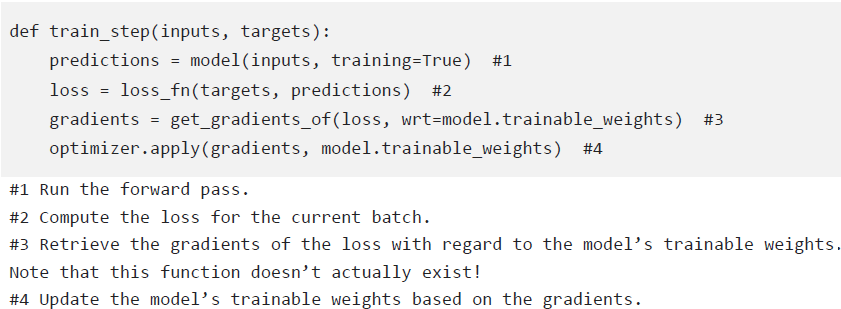

This snippet is pseudo-code rather than real code because it includes an imaginary function,
get_gradients_of(). In reality, retrieving gradients is done in a way that is specific to
your current backend – JAX, TensorFlow, or PyTorch.

Let’s use what you learned about each framework in Chapter 3 to implement a real
version of this train_step() function. We’ll start with TensorFlow and PyTorch, because
these two make the job relatively easy, so they’re a good place to start. We’ll end with JAX,
which is quite a bit more complex.

##### A TensorFlow training step function

TensorFlow lets you write code that looks pretty much like our pseudo-code snippet. The
only difference is that your forward pass should take place inside a GradientTape scope.
You can then use the tape object to retrieve the gradients.

In [49]:
%%backend tensorflow

import keras
from keras import layers

def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

In [50]:
%%backend tensorflow
import tensorflow as tf

model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

def train_step(inputs, targets):
    with tf.GradientTape() as tape:   # open a gradient tape scope
        predictions = model(inputs, training=True)    # run the forward pass
        loss = loss_fn(targets, predictions)
    gradients = tape.gradient(loss, model.trainable_weights)    # retrieve the gradients
    optimizer.apply(gradients, model.trainable_weights)    # update the models trainable weights
    return loss

Run for a single step

In [51]:
%%backend tensorflow
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]
loss = train_step(inputs, targets)

##### A PyTorch training step function

When you use the PyTorch backend, all of your Keras layers and models inherit from the
PyTorch torch.nn.Module class, and expose the native Module API. As a result, your
model, its trainable weights, and your loss tensor are all aware of each other and interact
via three methods: loss.backward(), weight.value.grad, and model.zero_grad().
As a reminder from Chapter 3, the mental model you’ve got to keep in mind is this:

With each forward pass, PyTorch builds up a one-time computation graph
that keeps track of the computation that just happened.

Calling .backward() on any given scalar node of this graph (like your
loss) will run the graph backward starting from that node, automatically
populating a tensor.grad attribute on all tensors involved (if they satisfy
requires_grad=True), containing the gradient of the output node with
respect to that tensor. In particular, it will populate the grad attribute of
your trainable parameters.

In order to clear the contents of that tensor.grad attribute, you should
call tensor.grad = None on all your tensors. Because it would be a bit
cumbersome to do this on all model variables individually, you can just do
it at the model level via model.zero_grad() – the zero_grad() call will
propagate to all variables tracked by the model. Clearing gradients is
critical, because calls to backward() are additive: if you don’t clear the
gradients at each step, the gradient values would accumulate and training
would not proceed.

In [52]:
%%backend torch

import keras
from keras import layers

def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

In [53]:
%%backend torch
import torch

model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

def train_step(inputs, targets):
    predictions = model(inputs, training=True)    # run forward pass
    loss = loss_fn(targets, predictions)    # get loss
    loss.backward()    # run the backwards pass, populating the gradient values
    gradients = [weight.value.grad for weight in model.trainable_weights]    # Recover the gradient associated with each trainable variable. Note that weight.value is the PyTorch tensor that contains the variable’s value.
    with torch.no_grad():    # Update the model’s trainable weights based on the gradients. This must be done ina no_grad() scope.
        optimizer.apply(gradients, model.trainable_weights)
    model.zero_grad()    # Don’t forget to clear the gradients!
    return loss

Run for a single step

In [54]:
%%backend torch
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]
loss = train_step(inputs, targets)

##### A JAX training step function

When it comes to low-level training code, JAX tends to be the most complex of the three
backends, because of its fully stateless nature. Statelessness makes JAX highly performant
and scalable, because it makes it amenable to compilation and automatic performance
optimizations. However, writing stateless code requires you to jump through some hoops.

Since the gradient function is obtained via metaprogramming, you first need to define
the function that returns your loss. Further, this function needs to be stateless, so it needs
to take as arguments all the variables it’s going to be using, and it needs to return the
value of any variable it has updated. Remember those “non-trainable weights” that can get
modified during the forward pass? Those are the variables we need to return.

To make it easier to work with the stateless programming paradigm of JAX, Keras
models make available a stateless forward pass method: the stateless_call() method. It
behaves just like __call__, except that:

It takes as input the model’s trainable weights and non-trainable weights,
in addition to the inputs and training arguments.

It returns the model’s updated non-trainable weights, in addition to the
model’s outputs.

It works like this:

outputs, non_trainable_weights = model.stateless_call(
trainable_weights, non_trainable_weights, inputs
)

We can use stateless_call() to implement our JAX loss function. Since the loss function
also computes updates for all non-trainable variables, we name it
compute_loss_and_updates():

In [55]:
%%backend jax

import keras
from keras import layers

def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

In [56]:
%%backend jax
model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()

def compute_loss_and_updates(    # Gradients are computed for the entries in the first argument (trainable_variables here)
    trainable_variables, non_trainable_variables, inputs, targets    # Gradients are computed for the entries in the first argument (trainable_variables here)
):
    outputs, non_trainable_variables = model.stateless_call(    # Call stateless_call.
        trainable_variables, non_trainable_variables, inputs
    )
    loss = loss_fn(targets, outputs)
    return loss, non_trainable_variables    # Return the scalar loss value and the updated non-trainable weights.

Once we have this compute_loss_and_updates() function, we can pass it to
jax.value_and_grad to obtain the gradient-computation:

import jax

grad_fn = jax.value_and_grad(fn)

loss, gradients = grad_fn(...)

Now, there’s just a small problem. Both jax.grad() and jax.value_and_grad() require fn
to return a scalar value only. Our compute_loss_and_updates() function returns a scalar
value as its first output, but it also returns the new value for the non-trainable weights.
Remember what you learned in Chapter 3? The solution is to pass a has_aux argument to
grad() or value_and_grad(), like this:

In [57]:
%%backend jax
import jax

grad_fn = jax.value_and_grad(compute_loss_and_updates, has_aux=True)

You would use it like this:

(loss, non_trainable_weights), gradients = grad_fn(
trainable_variables, non_trainable_variables, inputs, targets
)

Ok, that was a lot of JAXiness. But now we’ve got almost everything we need to assemble
our JAX training step. We just need the last piece of the puzzle: optimizer.apply().
When you wrote your first basic training step in TensorFlow at the beginning of Chapter
2, you wrote an update step function that looked like this:

learning_rate = 1e-3

def update_weights(gradients, weights):

for g, w in zip(gradients, weights):

w.assign(w - g * learning_rate)

This corresponds to what the optimizer keras.optimizers.SGD would do. However, every
other optimizer in the Keras API is somewhat more complex than that, and keeps track of
auxiliary variables that help speed up training – in particular, most optimizers leverage
some form of momentum, which you learned about in Chapter 2. These extra variables get
updated at each step of training, and in the JAX world, that means that you need to get
your hands on a stateless function that takes these variables as arguments and returns
their new value.

To make this easy, Keras makes available the stateless_apply() method on all
optimizers. It works like this:

trainable_variables, optimizer_variables = optimizer.stateless_apply(
optimizer_variables, grads, trainable_variables
)

Now, we have enough to assemble an end-to-end training step:

In [58]:
%%backend jax
optimizer = keras.optimizers.Adam()
optimizer.build(model.trainable_variables)

def train_step(state, inputs, targets):    # state is part of the function arguments
    (trainable_variables, non_trainable_variables, optimizer_variables) = state    # upack the state
    (loss, non_trainable_variables), grads = grad_fn(    # compute the gradients and updates to non-trainable variables
        trainable_variables, non_trainable_variables, inputs, targets
    )
    trainable_variables, optimizer_variables = optimizer.stateless_apply(    # update trainable variables and optimizer variables
        optimizer_variables, grads, trainable_variables
    )
    return loss, (    # return the updated state alongside the loss
        trainable_variables,
        non_trainable_variables,
        optimizer_variables,
    )

Run a single step:

In [59]:
%%backend jax
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]

trainable_variables = [v.value for v in model.trainable_variables]
non_trainable_variables = [v.value for v in model.non_trainable_variables]
optimizer_variables = [v.value for v in optimizer.variables]

state = (trainable_variables, non_trainable_variables, optimizer_variables)
loss, state = train_step(state, inputs, targets)

It’s definitely a bit more work than TensorFlow and PyTorch, but the speed and scalability
benefits of JAX more than make up for it.

Next, let’s take a look at another important element of a custom training loop: metrics.

#### Low-level usage of metrics

In a low-level training loop, you will probably want to leverage Keras metrics (whether
custom ones or the built-in ones). You’ve already learned about the metrics API: simply call
update_state(y_true, y_pred) for each batch of targets and predictions, then use
result() to query the current metric value.

In [60]:
from keras import ops

metric = keras.metrics.SparseCategoricalAccuracy()
targets = ops.array([0, 1, 2])
predictions = ops.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
metric.update_state(targets, predictions)
current_result = metric.result()
print(f"result: {current_result:.2f}")

result: 1.00


You may also need to track the average of a scalar value, such as the model’s loss. You can
do this via the keras.metrics.Mean metric:

In [61]:
values = ops.array([0, 1, 2, 3, 4])
mean_tracker = keras.metrics.Mean()
for value in values:
    mean_tracker.update_state(value)
print(f"Mean of values: {mean_tracker.result():.2f}")

Mean of values: 2.00


Remember to use metric.reset_state() when you want to reset the current results (at
the start of a training epoch or at the start of evaluation).

Now, if you’re using JAX, state-modifying methods like update_state() or reset() can’t
be used inside a stateless function. Instead, you can use the stateless metrics API, which is
similar to the model.stateless_call() and optimizer.stateless_apply() methods
you’ve already learned about. Here’s how it works:

In [62]:
metric = keras.metrics.SparseCategoricalAccuracy()
targets = ops.array([0, 1, 2])
predictions = ops.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

metric_variables = metric.variables    # get the metrics stae variables
metric_variables = metric.stateless_update_state(    # get updated values for the metrics state
    metric_variables, targets, predictions
)
current_result = metric.stateless_result(metric_variables)  # Compute the metric value corresponding to the current state
print(f"result: {current_result:.2f}")

metric_variables = metric.stateless_reset_state()    # Get blank variable values for the metric

result: 1.00


#### Leveraging `fit()` with a custom training loop

In the sections above, we were writing our own training logic entirely from scratch. Doing
so provides you with the most flexibility, but you end up writing a lot of code, while
simultaneously missing out on many convenient features of fit(), such as callbacks,
performance optimizations, or built-in support for distributed training.

What if you need a custom training algorithm, but you still want to leverage the power of
the built-in Keras training loop? There’s actually a middle ground between fit() and a
training loop written from scratch: you can provide a custom training step function and let
the framework do the rest.

You can do this by overriding the train_step() method of the Model class. This is the
function that is called by fit() for every batch of data. You will then be able to call fit()
as usual – and it will be running your own learning algorithm under the hood.
Here’s how it works:

Create a new class that subclasses keras.Model.

Override the train_step() method. Its contents are nearly identical to
what we used in the section above.

Return a dictionary mapping metric names (including the loss) to their
current value.

Note:

This pattern does not prevent you from building models with the
Functional API. You can do this whether you’re building Sequential
models, Functional API models, or subclassed models.

You don’t need to use a @tf.function or @jax.jit decorator when you
override train_step() – the framework does it for you.

##### Customizing `fit()` with TensorFlow

In [64]:
%%backend tensorflow
import keras
from keras import layers
import tensorflow as tf

loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")   # This metric object will be used to track the average of per-batch losses during training and evaluation

class CustomModel(keras.Model):
    def train_step(self, data):   # Override the train_step() method.
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)    # Note that we use self(inputs, training=True) instead of model(inputs, training=True), since our model is the class itself.
            loss = loss_fn(targets, predictions)
        gradients = tape.gradient(loss, model.trainable_weights)
        self.optimizer.apply(gradients, model.trainable_weights)

        loss_tracker.update_state(loss)    # Update the loss tracker metric that tracks the average of the loss.
        return {"loss": loss_tracker.result()}    # Return the average loss so far by querying the loss tracker metric

    @property    # Listing the loss tracker metric in the model.metrics property enables the model to automatically call reset_state() on it at the start of each epoch and at the start of a call to evaluate() – so you don’t have to do it by hand. Any metric you would like to reset across epochs should be listed here
    def metrics(self):
        return [loss_tracker]

We can now instantiate our custom model, compile it (we only pass the optimizer, since the
loss is already defined outside of the model), and train it using fit() as usual.
Let’s put the model definition in its own reusable function:

In [65]:
%%backend tensorflow
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

In [66]:
del model  # Delete the model object
keras.backend.clear_session() # Clear the Keras session

In [67]:
%%backend tensorflow

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.2869
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1461
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1168


##### Customizing `fit()` with PyTorch

In [69]:
%%backend torch

import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        predictions = self(inputs, training=True)    # Run the forward pass.
        loss = loss_fn(targets, predictions)

        loss.backward()
        trainable_weights = [v for v in self.trainable_weights]    # retrieve the gradients
        gradients = [v.value.grad for v in trainable_weights]

        with torch.no_grad():
            self.optimizer.apply(gradients, trainable_weights)    # update the weights

        loss_tracker.update_state(loss)    # update the loss tracker metric
        return {"loss": loss_tracker.result()}    # Return the average loss so far by querying the loss tracker metric.

    @property
    def metrics(self):
        return [loss_tracker]

In [70]:
%%backend torch

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
   1/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - loss: 2.3898

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 1.3336
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 1.4178
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 1.5314


##### Customizing `fit()` with JAX

Finally, let’s write the JAX version. First we need to define a compute_loss_and_updates()
method, similar to the compute_loss_and_updates() function we used in our custom
training step example.

Note we aren’t computing a moving average of the loss like we did for the other two
backends. Instead we just return the per-batch loss value, which is less useful. We do this
to simplify metric state management in the example: the code would get very verbose if we
included it. You will learn about metric management in the next section!

In [72]:
%%backend jax

import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = loss_fn(targets, predictions)
        return loss, non_trainable_variables    # Return both the loss and the updated non-trainable variables

    def train_step(self, state, data):
        (
            trainable_variables,    # Unpack the state. Note that metrics_variables are part of it – though we won’t use them here
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        ) = state
        inputs, targets = data

        grad_fn = jax.value_and_grad(    # Get the gradient function
            self.compute_loss_and_updates, has_aux=True
        )

        (loss, non_trainable_variables), grads = grad_fn(    # Compute gradients and updates to non-trainable variables
            trainable_variables,
            non_trainable_variables,
            inputs,
            targets,
            training=True,
        )

        (
            trainable_variables,    # Update trainable variables and optimizer variables
            optimizer_variables,
        ) = self.optimizer.stateless_apply(
            optimizer_variables, grads, trainable_variables
        )

        logs = {"loss": loss}    # Note we aren’t computing a moving average of the loss, instead returning the per-batch loss.
        state = (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        )
        return logs, state    # return metric logs and updated state variables

In [ ]:
%%backend jax
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

In [73]:
%%backend jax

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0000e+00
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0000e+00
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0000e+00


#### Handling metrics in a custom `train_step()`

Finally – what about the loss and metrics that you can pass to compile()? After you’ve
called compile(), you get access to:

self.compute_loss – this combines the loss function you passed to
compile(), together with regularization losses that may be added by
certain layers.

self.metrics – the list of metrics you passed to compile(). Note that it
also includes a metric that tracks the loss.

##### `train_step()` metrics handling with TensorFlow

Here’s what it looks like with TensorFlow:

In [75]:
%%backend tensorflow

import keras
from keras import layers

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = self.compute_loss(y=targets, y_pred=predictions)    # Compute the loss via self.compute_loss

        gradients = tape.gradient(loss, model.trainable_weights)
        self.optimizer.apply(gradients, model.trainable_weights)

        for metric in self.metrics:    # Update the model’s metrics, including the one that tracks the loss
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(targets, predictions)

        return {m.name: m.result() for m in self.metrics}    # Return a dict mapping metric names to their current value

In [76]:
%%backend tensorflow
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - sparse_categorical_accuracy: 0.9139 - loss: 0.2894
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - sparse_categorical_accuracy: 0.9557 - loss: 0.1463
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - sparse_categorical_accuracy: 0.9648 - loss: 0.1127


##### `train_step()` metrics handling with PyTorch

And here’s what it looks like with PyTorch – it’s exactly the same code change!

In [78]:
%%backend torch
import keras
from keras import layers

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        predictions = self(inputs, training=True)
        loss = self.compute_loss(y=targets, y_pred=predictions)

        loss.backward()
        trainable_weights = [v for v in self.trainable_weights]
        gradients = [v.value.grad for v in trainable_weights]

        with torch.no_grad():
            self.optimizer.apply(gradients, trainable_weights)

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(targets, predictions)

        return {m.name: m.result() for m in self.metrics}

In [79]:
%%backend torch
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - sparse_categorical_accuracy: 0.6636 - loss: 1.3662
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - sparse_categorical_accuracy: 0.5838 - loss: 1.5536
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - sparse_categorical_accuracy: 0.5528 - loss: 1.5129


##### `train_step()` metrics handling with JAX

Finally, here’s what it looks like with JAX.
To start with, you can just use compute_loss() in your compute_loss_and_updates()
method in order to hit the loss passed to compile():

In [80]:
%%backend jax
import keras
from keras import layers

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = self.compute_loss(y=targets, y_pred=predictions)
        return loss, (predictions, non_trainable_variables)
# metric management. As usual, it’s a tad more complicated due to JAX’s statelessness requirements.
    def train_step(self, state, data):
        (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,    # metric variables are part of the state
        ) = state
        inputs, targets = data

        grad_fn = jax.value_and_grad(
            self.compute_loss_and_updates, has_aux=True
        )

        (loss, (predictions, non_trainable_variables)), grads = grad_fn(
            trainable_variables,
            non_trainable_variables,
            inputs,
            targets,
            training=True,
        )
        (
            trainable_variables,
            optimizer_variables,
        ) = self.optimizer.stateless_apply(
            optimizer_variables, grads, trainable_variables
        )

        new_metrics_vars = []
        logs = {}
        for metric in self.metrics:    # iterate over the metrics
            num_prev = len(new_metrics_vars)
            num_current = len(metric.variables)
            current_vars = metrics_variables[num_prev : num_prev + num_current]    # grab the variables of the current metrics
            if metric.name == "loss":
                current_vars = metric.stateless_update_state(current_vars, loss)    # update the metrics state
            else:
                current_vars = metric.stateless_update_state(    # update the metrics state
                    current_vars, targets, predictions
                )
            logs[metric.name] = metric.stateless_result(current_vars)    # Store the results in the logs dict.
            new_metrics_vars += current_vars

        state = (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            new_metrics_vars,    # Return the new metrics variables as part of the state.
        )
        return logs, state

### Chapter summary

Keras offers a spectrum of different workflows, based on the principle of
progressive disclosure of complexity. They all smoothly interoperate.

You can build models via the Sequential class, via the Functional API, or
by subclassing the Model class. Most of the time, you’ll be using the
Functional API.

The simplest way to train and evaluate a model is via the default fit()
and evaluate() methods.

Keras callbacks provide a simple way to monitor models during your call
to fit() and automatically take action based on the state of the model.
You can also fully control what fit() does by overriding the
train_step() method, leveraging APIs from your backend of choice –
JAX, TensorFlow, or PyTorch.

Beyond fit(), you can also write your own training loops entirely from
scratch, in a backend-native way. This is useful for researchers
implementing brand new training algorithms.

# Table of different model types:

If your Yi's are one-hot encoded, use categorical_crossentropy. Examples (for a 3-class classification): [1,0,0] , [0,1,0], [0,0,1]

But if your Yi's are integers, use sparse_categorical_crossentropy. Examples for above 3-class classification problem: [1] , [2], [3]

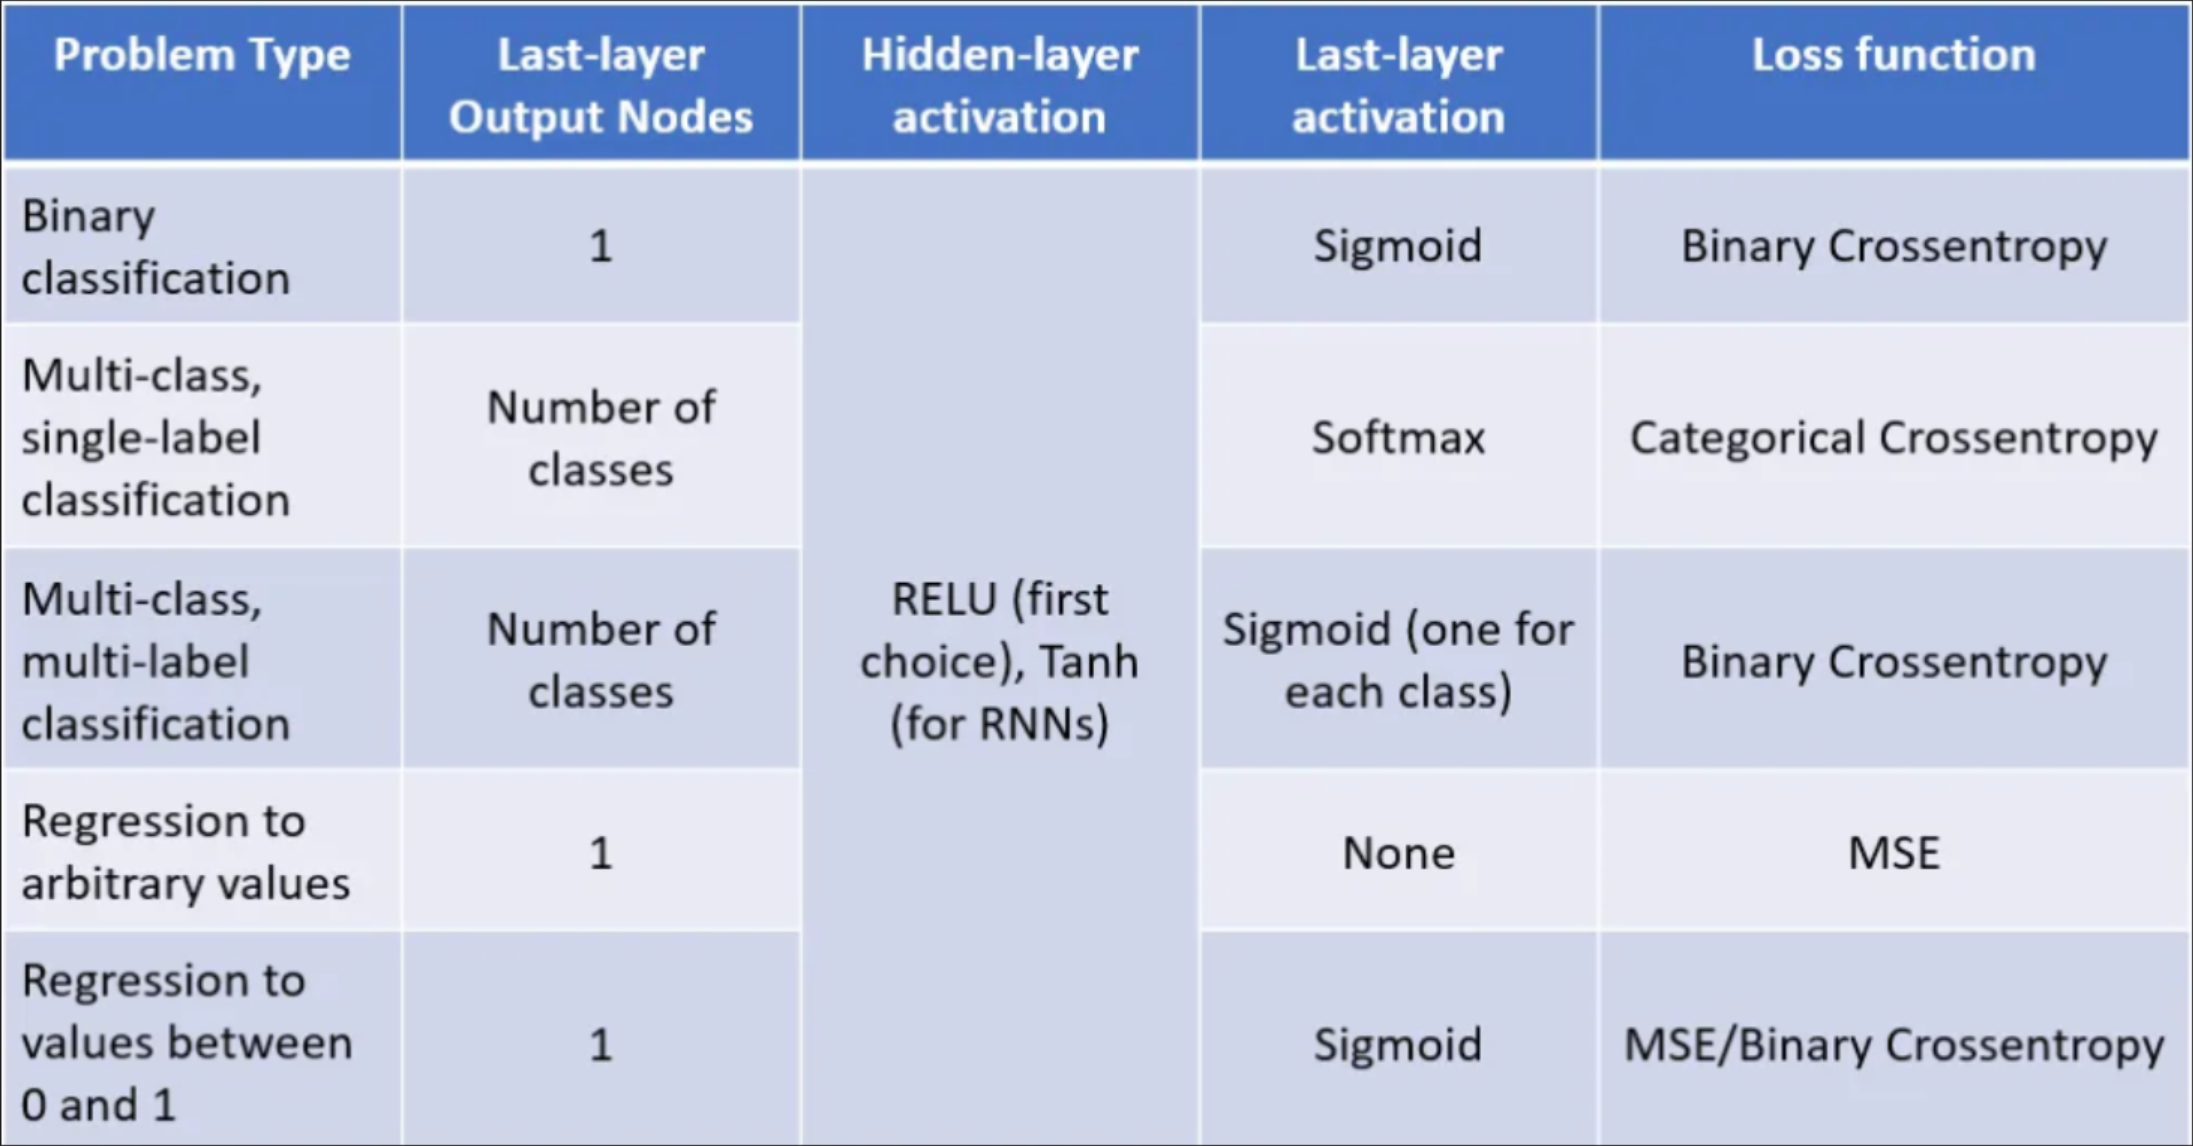

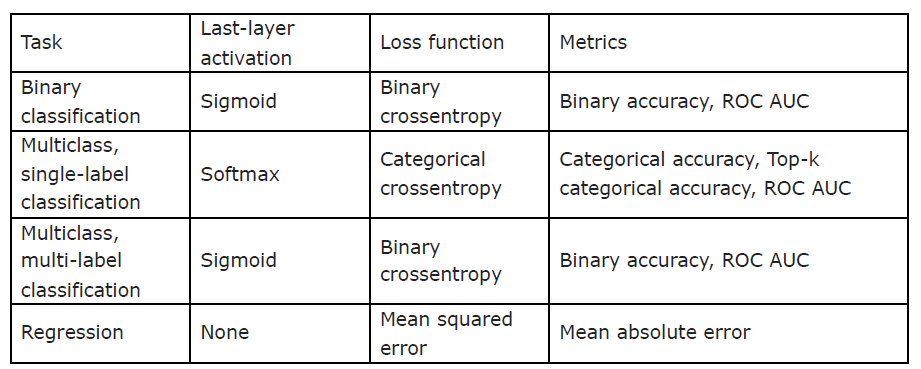